## 🧪 Classification Testing Notebook Overview

This notebook provides a complete, plug-and-play interface for evaluating our trained **cervical cancer classification model** on a set of labeled testing images. It is designed so that anyone can load the classifier, run predictions, compute accuracy/metrics, and visually inspect results — without needing to understand the underlying training pipeline.

### What this notebook does

- **Loads the trained classifier** saved in the `models/` folder  
  - `best_classifier_placeholder.pt` — placeholder name; replace with the actual model filename

- **Loads the testing images** and their corresponding labels from:  
  - `testing_images/` — contains all testing images  
  - `test_tags.csv` — contains ground-truth labels (`Cancer status`: 0 = Normal, 1 = Pre-cancerous, 2 = Cancerous)

- **Runs inference** on all testing images and computes:  
  - Overall accuracy  
  - Per-class precision, recall, and F1 score  
  - Confusion matrix (raw + normalized)

- Provides **utility functions** to:
  - Visualize a random sample of predictions  
  - Show predicted vs. true label and probability distribution per image  
  - Debug misclassifications and inspect model behavior

### Why this notebook is useful

- Provides a standardized evaluation workflow for all classification models.  
- Ensures consistent comparison across different backbones or training strategies.  
- Facilitates quick visual QC of model predictions and confidence scores.  
- Helps identify systematic errors (e.g., confusion between pre-cancerous vs. cancerous).

### Folder structure expected

```
for_testing/
│
├── testing_classification.ipynb # ← this notebook
│
├── testing_images/ # testing images + labels
│ ├── via_img_01.jpg
│ ├── via_img_02.png
│ ├── ...
│ └── test_tags.csv # contains "Cancer status" labels
│
└── models/
└── best_classifier_placeholder.pt
```


Use this notebook as a unified, repeatable way to test any new classification models we produce.


In [10]:
import os
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

# -------------------
# Paths (edit if needed)
# -------------------
ROOT_DIR = Path(".")  # notebook inside for_testing/
TEST_ROOT = ROOT_DIR

IMAGE_DIR = TEST_ROOT / "testing_images"
CSV_PATH  = IMAGE_DIR / "test_tags.csv"
MODEL_DIR = TEST_ROOT / "models"

# 🔁 placeholder model name – change this when you have the real file
CLASSIFIER_WEIGHTS = MODEL_DIR / "resnet_backbone_efficient_head_best.pth"

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Class mapping: 0-Normal, 1-Pre-cancerous, 2-Cancerous
CLASS_NAMES = ["Normal", "Pre-cancerous", "Cancerous"]
NUM_CLASSES = len(CLASS_NAMES)

print("Images path:", IMAGE_DIR)
print("CSV path   :", CSV_PATH)
print("Model path :", CLASSIFIER_WEIGHTS)


Using device: cpu
Images path: testing_images
CSV path   : testing_images\test_tags.csv
Model path : models\resnet_backbone_efficient_head_best.pth


In [11]:
# Read CSV
df = pd.read_csv(CSV_PATH)
print("Columns in CSV:", list(df.columns))

# Use the Cancer status column as labels
label_col = "Cancer status"
if label_col not in df.columns:
    raise ValueError(f"Expected '{label_col}' column in CSV but did not find it.")

print(f"Using label column: '{label_col}'")

records = []

for _, row in df.iterrows():
    # CSV already has full filename with extension
    filename = str(row["image"])          # e.g. "via_img_038_...jpg"
    label_int = int(row[label_col])       # 0, 1, or 2

    img_path = IMAGE_DIR / filename
    if not img_path.exists():
        print(f"⚠️ Image file not found at '{img_path}' – skipping")
        continue

    records.append(
        {
            "stem": filename,
            "path": img_path,
            "label": label_int,
        }
    )

print(f"\nResolved {len(records)} images from CSV.")
if len(records) == 0:
    raise RuntimeError("No images resolved – check that filenames in CSV match files in testing_images/")

# Convert to DataFrame for convenience
records_df = pd.DataFrame(records)
records_df.head()


Columns in CSV: ['image', 'Cancer status', 'Candidacy', 'image_path']
Using label column: 'Cancer status'

Resolved 19 images from CSV.


,stem,path,label
0,via_img_093_jpg.rf.39310d7eb930fab254db5821ea8...,testing_images\via_img_093_jpg.rf.39310d7eb930...,1
1,via_img_023_jpg.rf.96842e30a045893be04a7ef30bd...,testing_images\via_img_023_jpg.rf.96842e30a045...,1
2,via_img_088_jpg.rf.2803f449ad29eba0340d2267db8...,testing_images\via_img_088_jpg.rf.2803f449ad29...,0
3,via_img_036_jpg.rf.8a53d7ea45f3e505c4ff2bb7a6f...,testing_images\via_img_036_jpg.rf.8a53d7ea45f3...,1
4,via_img_050_jpg.rf.39b8d3b2f6b859d0ca3d067352d...,testing_images\via_img_050_jpg.rf.39b8d3b2f6b8...,0


In [12]:
# Standard ImageNet-like transforms (adjust if your model used something else)
IMG_SIZE = 224

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


class TestClassificationDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img_path = rec["path"]
        label = rec["label"]

        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)

        return img, label, str(img_path)


test_dataset = TestClassificationDataset(records, transform=test_transform)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Test dataset size: {len(test_dataset)} images")


Test dataset size: 19 images


In [13]:
from pathlib import Path
from torchvision import models
import torch.nn.functional as F

# === ResNet50 + EfficientHead architecture (matches training) ===

class EfficientHead(nn.Module):
    def __init__(self, in_features: int, num_classes: int = NUM_CLASSES, dropout: float = 0.3):
        super().__init__()
        # Must match training: 2048 -> 512 -> 128 -> num_classes
        self.fc1 = nn.Linear(in_features, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = nn.Linear(512, 128)
        self.bn2 = nn.BatchNorm1d(128)

        self.dropout = nn.Dropout(p=dropout)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        return x


def build_resnet50_with_eff_head_for_testing(num_classes: int = NUM_CLASSES, device: str = device):
    """
    Build the same ResNet-50 + EfficientHead architecture used in training.
    We load the final classifier weights (state_dict) separately.
    """
    model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = EfficientHead(in_features, num_classes)
    return model.to(device)


def load_classifier(weights_path: Path, num_classes: int = NUM_CLASSES):
    """
    Load classifier from a state_dict saved in weights_path.
    """
    if not weights_path.exists():
        raise FileNotFoundError(f"Classifier weights not found at: {weights_path}")

    # 1) Build architecture
    model = build_resnet50_with_eff_head_for_testing(num_classes=num_classes, device=device)

    # 2) Load state_dict
    state = torch.load(weights_path, map_location=device)

    # In case you saved {"state_dict": ...}
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]

    # Clean "module." prefixes if model was trained with DDP
    cleaned = {k.replace("module.", ""): v for k, v in state.items()}

    missing, unexpected = model.load_state_dict(cleaned, strict=False)
    print("Loaded ResNet-50 + EfficientHead classifier.")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    model.to(device)
    model.eval()
    return model


# === Instantiate model ===
classifier_model = load_classifier(CLASSIFIER_WEIGHTS, num_classes=NUM_CLASSES)
print("Model loaded and ready for evaluation.")


Loaded ResNet-50 + EfficientHead classifier.
Missing keys: []
Unexpected keys: []
Model loaded and ready for evaluation.


In [14]:
all_labels = []
all_preds  = []
all_probs  = []
all_paths  = []

softmax = nn.Softmax(dim=1)

classifier_model.eval()
with torch.no_grad():
    for imgs, labels, paths in test_loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)

        logits = classifier_model(imgs)
        probs  = softmax(logits)
        preds  = probs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy())
        all_paths.extend(paths)

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

print(f"Evaluated {len(all_labels)} images.")


Evaluated 19 images.


In [15]:
# Basic accuracy
accuracy = (all_labels == all_preds).mean()
print(f"Overall accuracy: {accuracy:.3f}")

# Detailed classification report
print("\nClassification report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=CLASS_NAMES,
        digits=3,
        zero_division=0,
    )
)

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
cm


Overall accuracy: 0.895

Classification report:
               precision    recall  f1-score   support

       Normal      1.000     0.778     0.875         9
Pre-cancerous      0.800     1.000     0.889         8
    Cancerous      1.000     1.000     1.000         2

     accuracy                          0.895        19
    macro avg      0.933     0.926     0.921        19
 weighted avg      0.916     0.895     0.894        19



array([[7, 2, 0],
       [0, 8, 0],
       [0, 0, 2]])

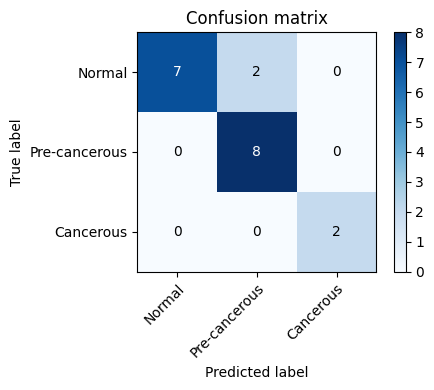

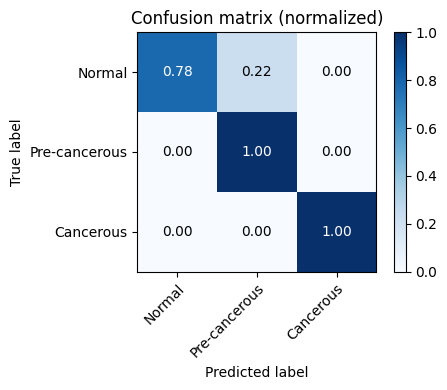

In [16]:
def plot_confusion_matrix(cm, class_names, normalize=False):
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True).clip(min=1e-9)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(cm.shape[1]),
        yticks=np.arange(cm.shape[0]),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="True label",
        xlabel="Predicted label",
        title="Confusion matrix" + (" (normalized)" if normalize else ""),
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], fmt),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    fig.tight_layout()
    plt.show()


plot_confusion_matrix(cm, CLASS_NAMES, normalize=False)
plot_confusion_matrix(cm, CLASS_NAMES, normalize=True)


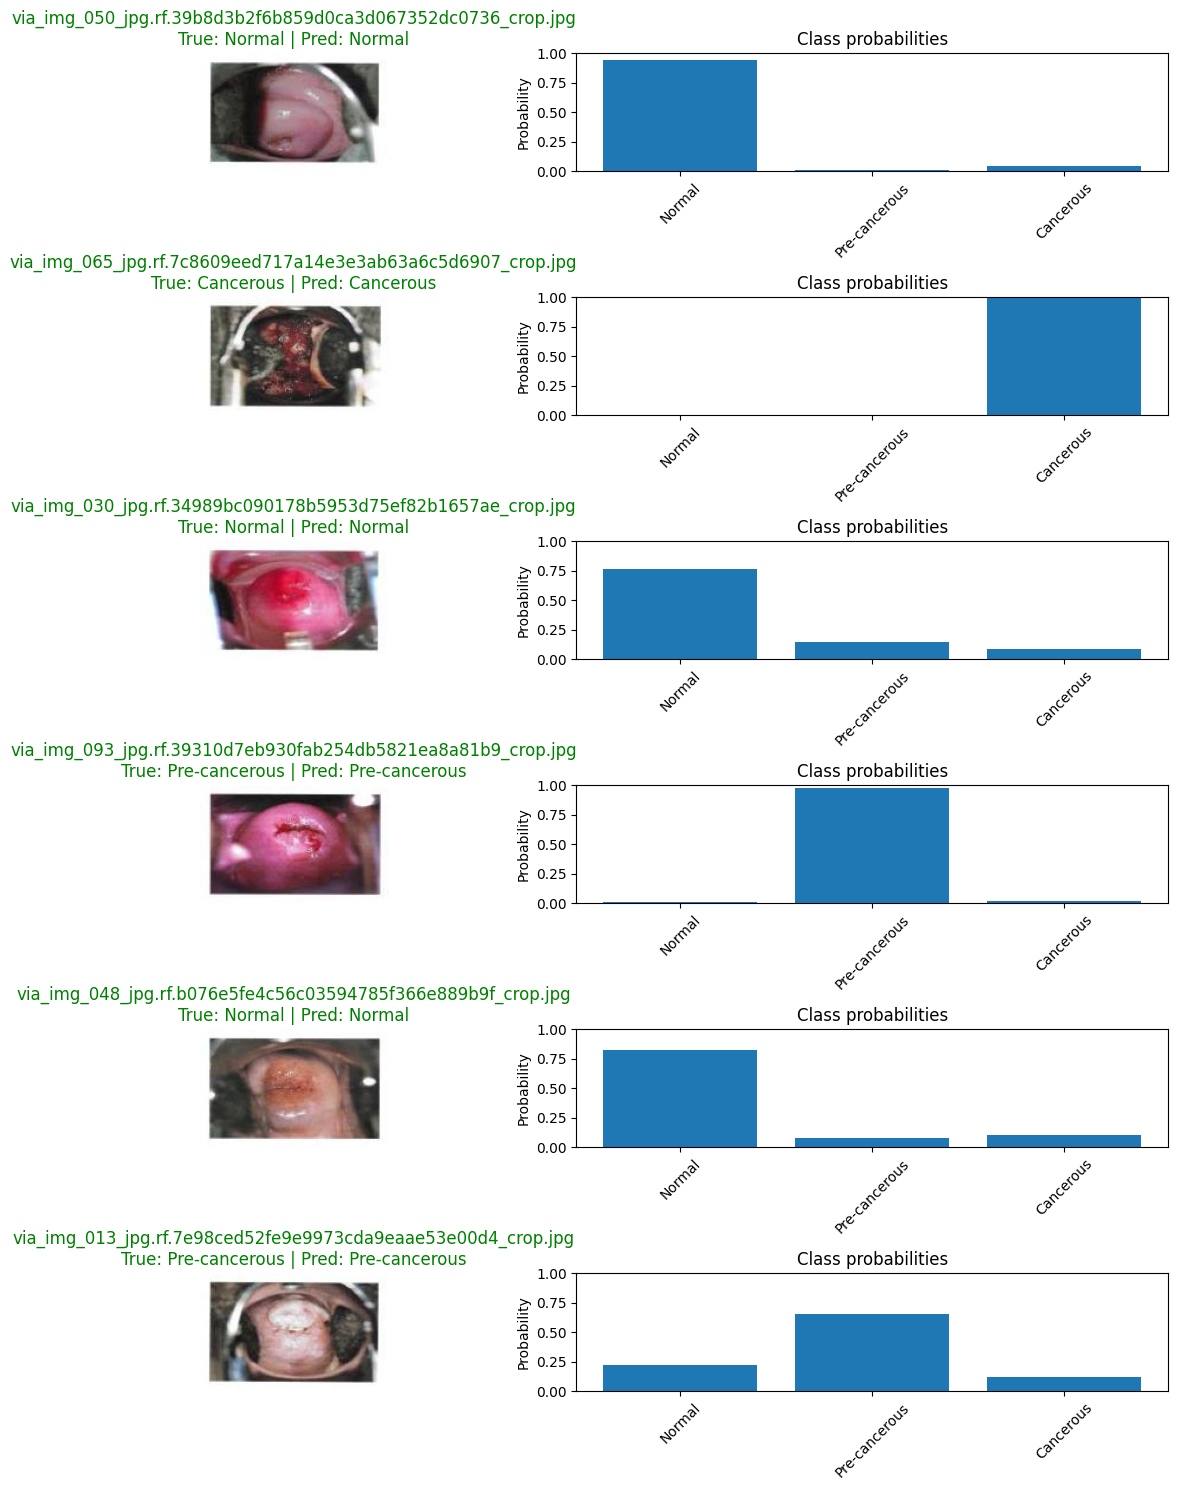

In [17]:
def show_predictions(n=6):
    n = min(n, len(all_paths))
    indices = np.random.choice(len(all_paths), size=n, replace=False)

    plt.figure(figsize=(12, 2.5 * n))

    for i, idx in enumerate(indices, start=1):
        img_path = all_paths[idx]
        true_lbl = all_labels[idx]
        pred_lbl = all_preds[idx]
        probs    = all_probs[idx]

        img = Image.open(img_path).convert("RGB")

        plt.subplot(n, 2, 2 * (i - 1) + 1)
        plt.imshow(img)
        plt.axis("off")

        title = f"{Path(img_path).name}\nTrue: {CLASS_NAMES[true_lbl]} | Pred: {CLASS_NAMES[pred_lbl]}"
        color = "green" if true_lbl == pred_lbl else "red"
        plt.title(title, color=color)

        # Plot probability bar chart
        plt.subplot(n, 2, 2 * (i - 1) + 2)
        plt.bar(range(NUM_CLASSES), probs)
        plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45)
        plt.ylim(0, 1)
        plt.ylabel("Probability")
        plt.title("Class probabilities")

    plt.tight_layout()
    plt.show()


show_predictions(n=6)
